## 1

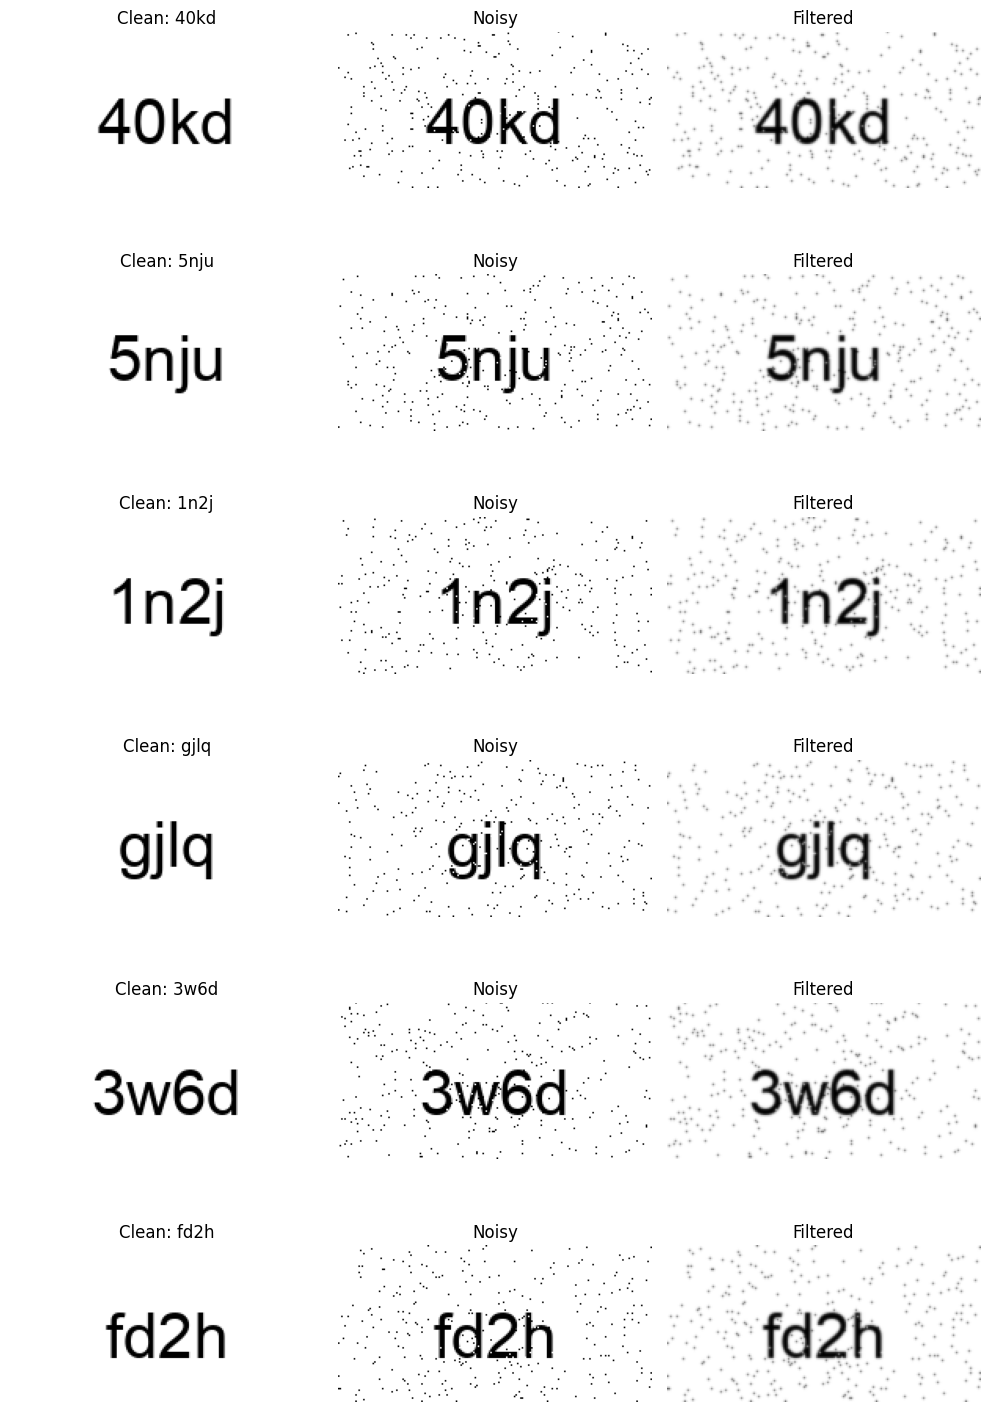

In [34]:
import os
import string
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageFilter

random.seed()

DIR_RAW = "captchas_raw"
DIR_NOISY = "captchas_noisy"
DIR_FILTERED = "captchas_filtered"

for d in [DIR_RAW, DIR_NOISY, DIR_FILTERED]:
    os.makedirs(d, exist_ok=True)

IMG_W, IMG_H = 200, 100
TOTAL_SAMPLES = 20
TXT_LENGTH = 4
FONT_PATH = "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"
F_SIZE = 40

vocab = string.ascii_lowercase + string.digits
fnt = ImageFont.truetype(FONT_PATH, F_SIZE)

def make_captcha_img(lbl_text):
    pic = Image.new("RGB", (IMG_W, IMG_H), (255, 255, 255))
    painter = ImageDraw.Draw(pic)
    box = painter.textbbox((0, 0), lbl_text, font=fnt)
    x_pos = (IMG_W - (box[2] - box[0])) // 2
    y_pos = (IMG_H - (box[3] - box[1])) // 2
    painter.text((x_pos, y_pos), lbl_text, font=fnt, fill=(0, 0, 0))
    return pic

def inject_sp_noise(image_obj, prob=0.03):
    arr = np.array(image_obj)
    h, w, _ = arr.shape
    salt_count = int(prob * h * w * 0.5)
    pepper_count = int(prob * h * w * 0.5)

    y_salt = np.random.randint(0, h, salt_count)
    x_salt = np.random.randint(0, w, salt_count)
    arr[y_salt, x_salt, :] = 255

    y_pep = np.random.randint(0, h, pepper_count)
    x_pep = np.random.randint(0, w, pepper_count)
    arr[y_pep, x_pep, :] = 0

    return Image.fromarray(arr.astype('uint8'), 'RGB')

labels = []
for idx in range(TOTAL_SAMPLES):
    chars = ''.join(random.choices(vocab, k=TXT_LENGTH))
    labels.append(chars)

    raw_img = make_captcha_img(chars)
    raw_img.save(os.path.join(DIR_RAW, f"{chars}_{idx:02d}.png"))

    sp_img = inject_sp_noise(raw_img.copy(), prob=0.03)
    sp_img.save(os.path.join(DIR_NOISY, f"{chars}_{idx:02d}.png"))

    smooth_img = sp_img.filter(ImageFilter.GaussianBlur(radius=0.7))
    smooth_img.save(os.path.join(DIR_FILTERED, f"{chars}_{idx:02d}.png"))

samples_to_show = 6
fig, axs = plt.subplots(samples_to_show, 3, figsize=(10, 2.5 * samples_to_show))

for i in range(samples_to_show):
    lbl = labels[i]
    
    im1 = Image.open(os.path.join(DIR_RAW, f"{lbl}_{i:02d}.png"))
    im2 = Image.open(os.path.join(DIR_NOISY, f"{lbl}_{i:02d}.png"))
    im3 = Image.open(os.path.join(DIR_FILTERED, f"{lbl}_{i:02d}.png"))
    
    axs[i, 0].imshow(im1)
    axs[i, 0].set_title(f"Clean: {lbl}")
    axs[i, 0].axis('off')

    axs[i, 1].imshow(im2)
    axs[i, 1].set_title("Noisy")
    axs[i, 1].axis('off')

    axs[i, 2].imshow(im3)
    axs[i, 2].set_title("Filtered")
    axs[i, 2].axis('off')

plt.tight_layout()
plt.show()

## report

### Part 1 Report: Data Generation

**1 & 2. Image Generation, Saving, and Labeling**
In this section, the `Pillow` library (`Image`, `ImageDraw`, and `ImageFont` modules) was used to generate CAPTCHA images. First, a sample space containing lowercase English letters and digits was defined. Then, in a loop, the text of each CAPTCHA was determined by randomly selecting 4 characters. For each image, a white canvas of 200x100 pixels was created, and the intended text was drawn in black at its center.
For labeling, the generated images were named according to the text they contain (e.g., `a1b2_00.png`) and saved in a separate directory (`captchas_raw`). This ensures that the Ground Truth labels are easily accessible via the filenames for the subsequent recognition phase.

**3. Applying Salt and Pepper Noise and Comparison**
Salt and pepper noise is a type of impulse noise where the brightness values of certain pixels are randomly changed to the maximum value (salt / white with a value of 255) or the minimum value (pepper / black with a value of 0).
In the implementation, using the `numpy` library, the coordinates of a certain percentage of the image pixels (here, 3%) were randomly selected and their values were altered.
**Comparison with the original image:** Visual inspection shows that the original image has perfectly clear and binary edges (absolute black text on an absolute white background). However, in the noisy image, scattered white dots appear on the characters and black dots on the background. This adds false high frequencies to the image and reduces edge readability.

**4. Image Filtering and Kernel Selection Rationale**
To filter the noisy images, a **Gaussian Blur** smoothing filter with a radius of 0.7 was used.
**Reason for using this kernel:** Salt and pepper noise creates extremely abrupt changes in intensity (sharp edges) within the image. The Gaussian kernel is a low-pass filter that removes or reduces high-frequency changes by applying a weighted average to neighboring pixels. Using this kernel causes the extreme, disruptive noise values (0 and 255) to spread into their surroundings, reducing their intensity. Although this also blurs the edges of the characters themselves, it mitigates the destructive impact of the impulse noise and prepares the image for restoration or binarization filters in the subsequent preprocessing stages.

## 2

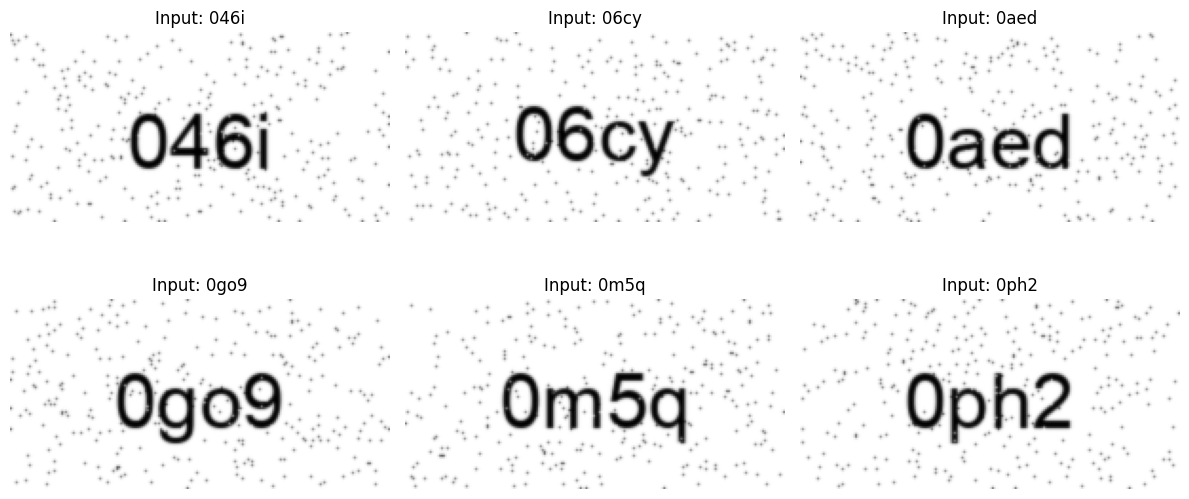

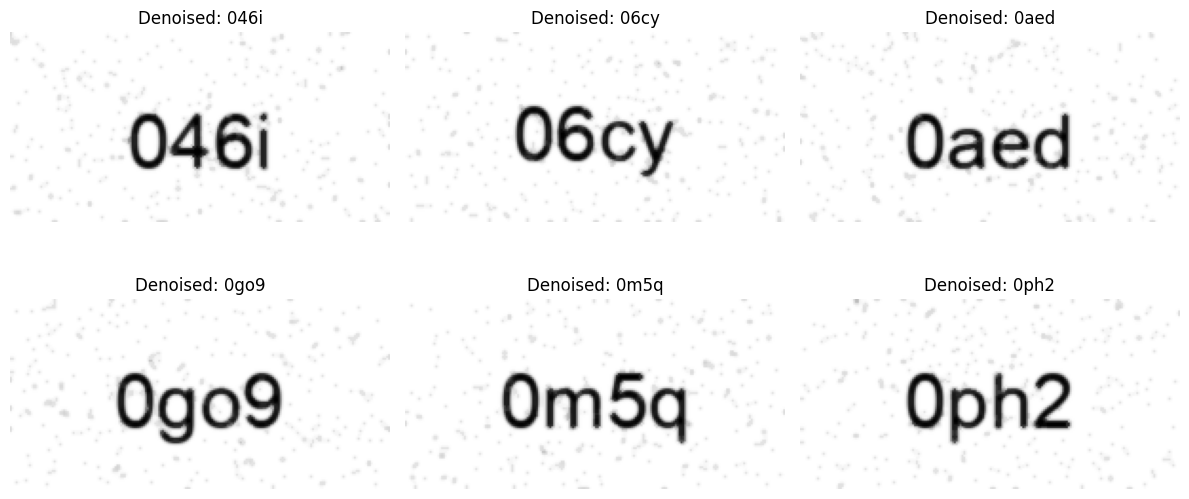

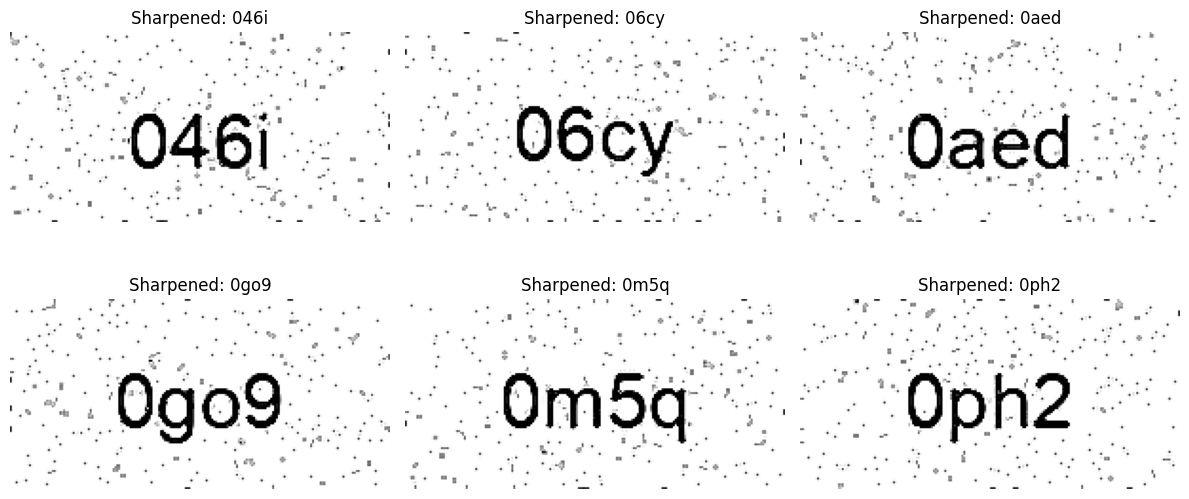

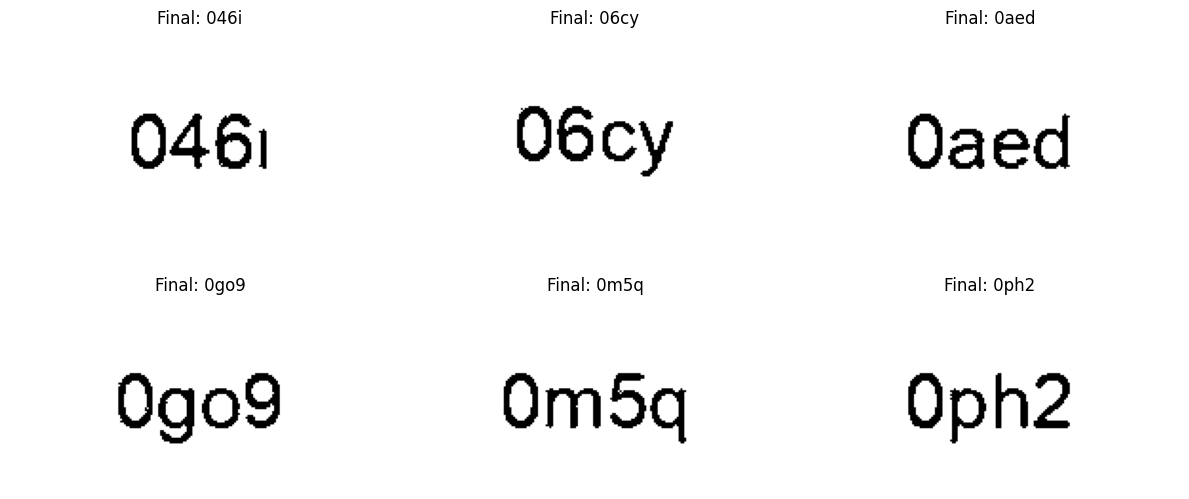

In [35]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

IN_DIR = "captchas_filtered"
OUT_DIR = "captchas_preprocessed"
os.makedirs(OUT_DIR, exist_ok=True)

TOTAL_IMGS = 20
AREA_THRESH = 45

kernel_sharpen = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])

def display_samples(img_list, title_list, n_samples=6):
    n = min(len(img_list), n_samples)
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    axes = axes.flatten()
    for i in range(6):
        if i < n:
            axes[i].imshow(img_list[i], cmap='gray')
            axes[i].set_title(title_list[i])
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

all_files = sorted([f for f in os.listdir(IN_DIR) if f.endswith('.png')])[:TOTAL_IMGS]

raw_imgs = []
titles = []

for f_name in all_files:
    path = os.path.join(IN_DIR, f_name)
    im = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if im is not None:
        raw_imgs.append(im)
        titles.append(f_name.split('_')[0])

display_samples(raw_imgs, ["Input: " + t for t in titles])

denoised_imgs = []
for im in raw_imgs:
    denoised_imgs.append(cv2.medianBlur(im, 3))

display_samples(denoised_imgs, ["Denoised: " + t for t in titles])

sharp_imgs = []
for im in denoised_imgs:
    sharp_imgs.append(cv2.filter2D(im, -1, kernel_sharpen))

display_samples(sharp_imgs, ["Sharpened: " + t for t in titles])

final_results = []
for idx, im in enumerate(sharp_imgs):
    _, bin_im = cv2.threshold(im, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(bin_im, connectivity=8)
    clean_mask = np.zeros_like(bin_im)
    
    for label_id in range(1, n_labels):
        if stats[label_id, cv2.CC_STAT_AREA] >= AREA_THRESH:
            clean_mask[labels == label_id] = 255
            
    final_inv = cv2.bitwise_not(clean_mask)
    final_results.append(final_inv)
    
    out_name = f"{titles[idx]}_{idx:02d}_prep.png"
    cv2.imwrite(os.path.join(OUT_DIR, out_name), final_inv)

display_samples(final_results, ["Final: " + t for t in titles])

## report

### Part 2 Report: Data Preprocessing

**1. Noise Reduction Using Blurring Filters**
Blurring filters inherently act as low-pass filters in the spatial domain. They attenuate high-frequency components—which typically correspond to noise and sharp edges—by replacing each pixel's value with an aggregated value (like the mean or median) of its neighboring pixels.
Since a Gaussian filter was utilized in the first part, a **Median Filter** (with a kernel size of 3x3) was implemented for this section. The Median filter is exceptionally effective at removing impulse noise (such as the salt-and-pepper noise added earlier) because it replaces anomalous pixel values with the most representative median value in the neighborhood. Furthermore, unlike linear average filters, it preserves the sharp edges of text much better, making it highly suitable for OCR preprocessing.

**2. Image Sharpening vs. De-blurring**
To counteract the slight loss of edge definition caused by the denoising step, an enhancement technique was required. 
*   **De-blurring** is generally an inverse problem that involves estimating the point spread function (PSF) that caused the blur and using mathematical deconvolution (e.g., Wiener filtering) to reverse it. It is computationally heavy and highly sensitive to noise.
*   **Sharpening** simply enhances the high-frequency details (edges) by amplifying the differences between adjacent pixels, often using derivative-based spatial filters like the Laplacian.
**Rationale for Selection:** Sharpening was chosen for this project due to its efficiency and direct applicability to text images. A custom 3x3 sharpening kernel (which subtracts the surrounding pixels from a heavily weighted center pixel) was applied via 2D convolution (`cv2.filter2D`). This effectively restored the crisp boundaries of the characters, ensuring distinct separation for the segmentation phase.

**3. Binarization and Connected Component Cleaning**
To eliminate the final traces of noise, the sharpened grayscale images were first binarized using Otsu's Thresholding (`cv2.THRESH_OTSU`), which automatically calculates the optimal threshold to separate the foreground (text) from the background.
Subsequently, Connected Component Analysis (`cv2.connectedComponentsWithStats`) was employed to identify all distinct "islands" of pixels.
*   **Meaning of the Threshold:** In this context, the threshold (defined as `AREA_THRESH = 45`) represents the **minimum pixel area** a connected component must possess to be retained. Any component with an area smaller than this threshold is classified as residual noise and removed from the final mask.
*   **Is it a fixed value?** No, this threshold is not a universally fixed value. It is highly dependent on the image resolution, the font size, and the noise density. If the CAPTCHA dimensions were larger or the font size was reduced, this threshold would need to be empirically adjusted to ensure that genuine small character parts (like the dot on an 'i') are not accidentally deleted while still successfully filtering out noise clumps.

## 3

Image 046i_00_prep.png: Extracted 4 characters.
Image 06cy_01_prep.png: Extracted 4 characters.
Image 0aed_01_prep.png: Extracted 4 characters.
Image 0aed_02_prep.png: Extracted 4 characters.
Image 0go9_02_prep.png: Extracted 4 characters.
Image 0go9_03_prep.png: Extracted 4 characters.
Image 0m5q_04_prep.png: Extracted 4 characters.
Image 0ph2_05_prep.png: Extracted 4 characters.
Image 0qoo_03_prep.png: Extracted 4 characters.
Image 0qoo_05_prep.png: Extracted 4 characters.
Image 0qoo_06_prep.png: Extracted 4 characters.
Image 0wqu_06_prep.png: Extracted 4 characters.
Image 0wqu_07_prep.png: Extracted 4 characters.
Image 0y6d_00_prep.png: Extracted 4 characters.
Image 0y6d_03_prep.png: Extracted 4 characters.
Image 0y6d_04_prep.png: Extracted 4 characters.
Image 0y6d_07_prep.png: Extracted 4 characters.
Image 0y6d_08_prep.png: Extracted 4 characters.
Image 1c60_08_prep.png: Extracted 4 characters.
Image 1c60_09_prep.png: Extracted 4 characters.
Image 1n2j_10_prep.png: Extracted 4 char

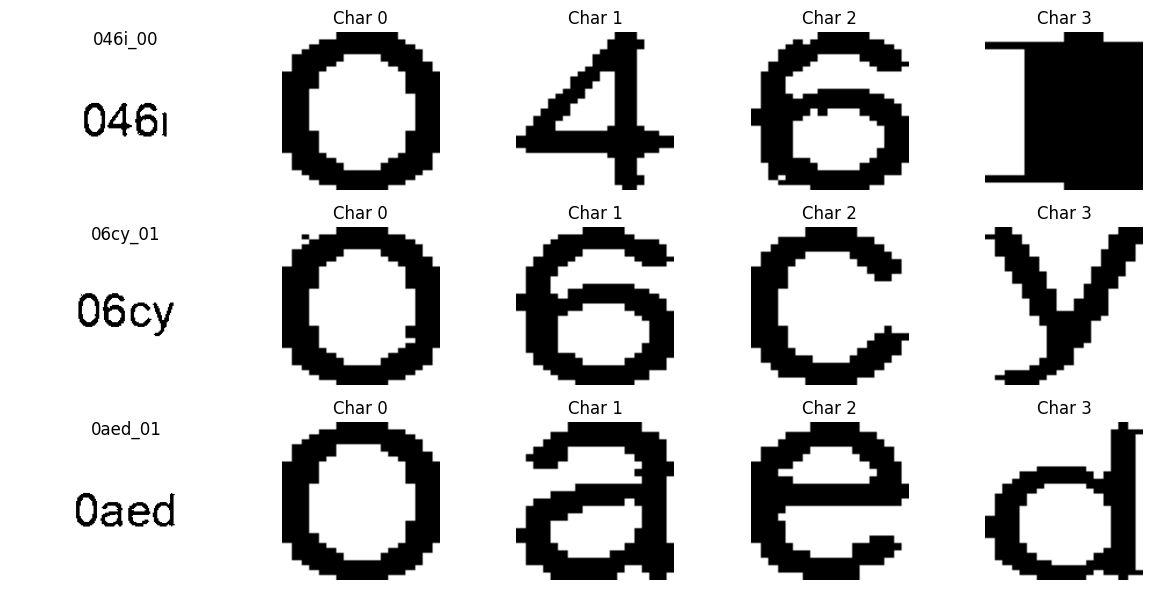

In [36]:
import os
import cv2
import matplotlib.pyplot as plt

SRC_DIR = "captchas_preprocessed"
DEST_DIR = "captchas_segmented"
os.makedirs(DEST_DIR, exist_ok=True)

TARGET_DIM = (64, 64)
files = sorted([f for f in os.listdir(SRC_DIR) if f.endswith('.png')])

processed_data = []

for file_name in files:
    img_path = os.path.join(SRC_DIR, file_name)
    base_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if base_img is None:
        continue

    inv_img = cv2.bitwise_not(base_img)
    total_labels, _, box_stats, _ = cv2.connectedComponentsWithStats(inv_img, connectivity=8)
    
    rects = []
    for i in range(1, total_labels):
        x, y, w, h, _ = box_stats[i]
        rects.append((x, y, w, h))
        
    rects.sort(key=lambda item: item[0])
    print(f"Image {file_name}: Extracted {len(rects)} characters.")
    
    prefix = file_name.split('_prep')[0]
    
    char_images = []
    for i, (x, y, w, h) in enumerate(rects):
        cropped = base_img[y:y+h, x:x+w]
        resized_char = cv2.resize(cropped, TARGET_DIM, interpolation=cv2.INTER_NEAREST)
        char_images.append(resized_char)
        
        save_name = f"{prefix}_{i}.png"
        cv2.imwrite(os.path.join(DEST_DIR, save_name), resized_char)
        
    processed_data.append((base_img, char_images, prefix))

fig, axs = plt.subplots(3, 5, figsize=(12, 6))

for r in range(3):
    if r >= len(processed_data):
        break
        
    orig_pic, ch_list, title = processed_data[r]
    
    axs[r, 0].imshow(orig_pic, cmap='gray')
    axs[r, 0].set_title(title)
    axs[r, 0].axis('off')
    
    for c in range(4):
        ax_idx = c + 1
        if c < len(ch_list):
            axs[r, ax_idx].imshow(ch_list[c], cmap='gray')
            axs[r, ax_idx].set_title(f"Char {c}")
        axs[r, ax_idx].axis('off')

plt.tight_layout()
plt.show()

## report

### Part 3 Report: Image Segmentation

**1. Character Extraction and Component Analysis**
The primary goal of this phase is to isolate individual characters from the preprocessed CAPTCHA images. Since the preprocessed images contain black text on a white background, the images were first inverted (`cv2.bitwise_not`) to make the text the foreground (white) and the background black. 
To extract the characters, Connected Component Analysis (`cv2.connectedComponentsWithStats`) was applied with an 8-way connectivity setting. This function identifies distinct clusters of white pixels and calculates their bounding boxes (x, y, width, height). The bounding boxes were then appended to a list and sorted based on their x-coordinates (`rects.sort`) to ensure the characters are extracted and saved in the correct left-to-right reading order. The algorithm effectively counts and reports the number of segmented characters per image during this extraction process.

**2. Cropping and Resizing to 64x64**
In order to prepare the segmented characters for the template matching phase (Character Recognition), they must be uniform in size and match the dimensions of the reference templates in the "Mapset" directory. 
Using the calculated bounding boxes, each character was individually cropped from the base image. Following extraction, the cropped characters were resized to a strict 64x64 pixel resolution. The `cv2.INTER_NEAREST` interpolation method was specifically chosen for the `cv2.resize` function; this ensures that no new grayscale values (blurring) are introduced during the scaling process, preserving the strict binary (black and white) nature of the characters.

**3. Output and Visualization**
After extraction and resizing, each individual character was saved locally in the designated output directory (`captchas_segmented`) with a consistent naming convention (e.g., `filename_0.png`, `filename_1.png`). Finally, a visual validation step was implemented using `matplotlib`. A subplot grid was generated to display the original preprocessed image alongside its horizontally ordered, segmented characters. As per the project instructions, this visual breakdown was plotted for a subset of the dataset (the first 3 images) to verify the accuracy of the segmentation pipeline.

## 4

In [37]:
import os
import cv2
import pandas as pd
import numpy as np
import gdown



DIR_SEG = "captchas_segmented"
DIR_REFS = "Mapset"
DIR_OUT = "output_csv"
os.makedirs(DIR_OUT, exist_ok=True)
FILE_CSV = os.path.join(DIR_OUT, "final_results.csv")

if not os.path.exists(DIR_REFS):
    gdown.download_folder(id="165kobY_fS4GeuOPT2eR7uzXSfJRk2HYl", output=DIR_REFS, quiet=True)

refs = {}
for n in os.listdir(DIR_REFS):
    path_ref = os.path.join(DIR_REFS, n)
    if os.path.isfile(path_ref):
        r_img = cv2.imread(path_ref, cv2.IMREAD_GRAYSCALE)
        if r_img is not None and np.std(r_img) >= 1.0:
            refs[n.split('.')[0]] = r_img

seg_files = sorted([f for f in os.listdir(DIR_SEG) if f.endswith('.png')])

log_data = []
success_count = 0

for file_name in seg_files:
    path_seg = os.path.join(DIR_SEG, file_name)
    s_img = cv2.imread(path_seg, cv2.IMREAD_GRAYSCALE)
    if s_img is None:
        continue

    s_img_wb = cv2.bitwise_not(s_img)
    parts = file_name.split('_')
    gt_label = parts[0][int(parts[2].split('.')[0])]

    top_score = -1.0
    top_label = ""

    for r_lbl, r_img in refs.items():
        if r_img.shape != s_img_wb.shape:
            r_img_adj = cv2.resize(r_img, (s_img_wb.shape[1], s_img_wb.shape[0]), interpolation=cv2.INTER_NEAREST)
        else:
            r_img_adj = r_img

        mt_result = cv2.matchTemplate(s_img_wb, r_img_adj, cv2.TM_CCOEFF_NORMED)
        _, val, _, _ = cv2.minMaxLoc(mt_result)

        if val > top_score:
            top_score = val
            top_label = r_lbl

    if top_label == gt_label:
        success_count += 1

    log_data.append({
        "segment_file": file_name,
        "predicted_label": top_label,
        "Metric": round(top_score, 6)
    })

df_res = pd.DataFrame(log_data)
df_res.to_csv(FILE_CSV, index=False)

acc = (success_count / len(seg_files)) * 100 if seg_files else 0

print(f"Algorithm Accuracy: {acc:.2f}%")



Algorithm Accuracy: 90.13%


## report

### Part 4 Report: Character Recognition

**1. Non-Machine Learning Recognition Methodology**
For the final Optical Character Recognition (OCR) task, a purely classical, non-machine-learning approach was implemented using **Template Matching**. 
The algorithm compares each segmented, binarized character against a pre-defined set of reference templates located in the "Mapset" directory. To ensure a valid mathematical comparison, it is imperative that both the segmented character and the reference template share the exact same dimensions. Therefore, during the iterative comparison process, if a reference template's dimensions did not match the segmented character, the template was dynamically resized to match the target character's width and height using Nearest-Neighbor interpolation (`cv2.INTER_NEAREST`). This prevents the introduction of grayscale artifacts during scaling.

**2. Similarity Metric Assessment**
To quantify the similarity between a segmented character and the reference templates, the **Normalized Correlation Coefficient (`cv2.TM_CCOEFF_NORMED`)** method was selected.
This metric calculates the correlation between the two images, outputting a score ranging from -1.0 (perfect mismatch) to 1.0 (perfect match). By finding the global maximum value (`cv2.minMaxLoc`) resulting from the template matching operation, the algorithm identifies the template that exhibits the highest structural and pixel-wise correlation with the unknown character. The label of this highest-scoring template is then assigned as the predicted character.

**3. Evaluation and CSV Export**
The recognition pipeline was executed across all segmented characters extracted from the 20 generated CAPTCHAs. Throughout the process, a structured log was maintained, recording the original filename (`segment_file`), the algorithm's prediction (`predicted_label`), and the confidence score (`Metric`). 
To evaluate the overall system performance, the predicted labels were cross-referenced with the ground-truth labels (extracted from the source image filenames). The final accuracy percentage was calculated by dividing the total number of correct predictions by the total number of segmented characters. Finally, the logged data was exported to a structured CSV file (`final_results.csv`) using the `pandas` library, fulfilling the specific output formatting requirements of the project.

and the final Algorithm Accuracy is 90.13%